In [1]:
# ============================================================
# V2 CHANGELOG (what this notebook fixes vs v1)
#  F1 stress test now flips _wasna with injected NaN (deployment-faithful)
#  F2 test-mean-prediction upshift decomposed with features-only diagnostic
#  F3 LR evaluated under the SAME 3x5 repeated protocol as LGBM (fair paired test)
#  F4 <30 subgroup: CI on FINAL model + explicit referral rule
#  F5 single clean pass; submission written ONLY in the last cell
# ============================================================
import numpy as np, pandas as pd, glob
import sklearn, lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression

SEED = 42
np.random.seed(SEED)
for m in (np, pd, sklearn, lgb): print(f"{m.__name__}: {m.__version__}")

tr_path = glob.glob("../../data/train.csv", recursive=True)[0]
te_path = glob.glob("../../data/test.csv", recursive=True)[0]
ss_path = glob.glob("../../data/sample_submission.csv", recursive=True)[0]
train, test, ss = (pd.read_csv(p) for p in (tr_path, te_path, ss_path))
ID, TARGET = "patient_id", "readmitted_30d"
y = train[TARGET].values.astype(int)
print("train", train.shape, "| test", test.shape, "| prevalence", round(y.mean(), 6))

numpy: 2.1.3
pandas: 2.2.3
sklearn: 1.9.0
lightgbm: 4.7.0
train (7000, 25) | test (3000, 24) | prevalence 0.125857


In [2]:
def engineer(d):
    d = d.copy()
    d["n_chronic"] = d[["diabetes","hypertension","chronic_kidney_disease","heart_failure"]].sum(axis=1)
    d["prior_x_comorb"] = d["prior_admissions_12m"] * d["comorbidity_count"]
    d["abn_creatinine"] = (d["creatinine_mg_dl"] > 1.2).astype(int)
    d["abn_sodium"]     = (d["sodium_mmol_l"]    < 135).astype(int)
    d["abn_hemoglobin"] = (d["hemoglobin_g_dl"]  < 12).astype(int)
    d["abn_sysbp"]      = ((d["systolic_bp_mmhg"] >= 140) | (d["systolic_bp_mmhg"] < 100)).astype(int)
    d["abn_heartrate"]  = (d["heart_rate_bpm"]   > 100).astype(int)
    d["n_abnormal_labs"] = d[["abn_creatinine","abn_sodium","abn_hemoglobin","abn_sysbp","abn_heartrate"]].sum(axis=1)
    return d

tr_e, te_e = engineer(train), engineer(test)
CATS = ["sex","rurality","hospital_type","region","discharge_disposition","care_pathway"]
NUMS = [c for c in tr_e.columns if c not in CATS + [ID, TARGET]]
NA_COLS = [c for c in NUMS if tr_e[c].isna().any()]
for d in (tr_e, te_e):
    for c in NA_COLS: d[c + "_wasna"] = d[c].isna().astype(int)
NUMS = [c for c in tr_e.columns if c not in CATS + [ID, TARGET]]
X_raw, Xte_raw = tr_e[NUMS + CATS], te_e[NUMS + CATS]
print(f"{len(NUMS)} numeric + {len(CATS)} categorical | NA-flagged: {NA_COLS}")

def make_pre_lr(nums, cats):   # LR needs scaling; drop=first -> identifiable ORs
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), nums),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cats)])
def make_pre(nums, cats):      # trees: scale-invariant, no drop needed
    return ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), nums),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cats)])
def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6); return np.log(p / (1 - p))

31 numeric + 6 categorical | NA-flagged: ['followup_days', 'hemoglobin_g_dl', 'creatinine_mg_dl', 'sodium_mmol_l', 'heart_rate_bpm', 'systolic_bp_mmhg']


In [3]:
skf0 = StratifiedKFold(5, shuffle=True, random_state=SEED)
grid = {}
for C in [0.1, 1.0, 10.0]:
    p = cross_val_predict(Pipeline([("pre", make_pre_lr(NUMS, CATS)),
                                    ("clf", LogisticRegression(max_iter=3000, C=C))]),
                          X_raw, y, cv=skf0, method="predict_proba")[:, 1]
    grid[C] = log_loss(y, p); print(f"LR C={C}: OOF logloss {grid[C]:.5f}")
BEST_C = min(grid, key=grid.get)

def run_repeated_cv_lr(C, cats, R=3, K=5, tag="LR"):
    oof = np.zeros((R, len(y)))
    for r in range(R):
        cv = StratifiedKFold(K, shuffle=True, random_state=SEED + 100 + r)
        pipe = Pipeline([("pre", make_pre_lr(NUMS, cats)),
                         ("clf", LogisticRegression(max_iter=3000, C=C))])
        oof[r] = cross_val_predict(pipe, X_raw, y, cv=cv, method="predict_proba")[:, 1]
        print(f"  {tag} repeat {r+1}: logloss {log_loss(y, oof[r]):.5f}")
    return oof

oof_lr = run_repeated_cv_lr(BEST_C, CATS)
p_lr = oof_lr.mean(0)
lls_lr = [log_loss(y, oof_lr[r]) for r in range(3)]
print(f"\nFROZEN LR C={BEST_C} | pooled LL {np.mean(lls_lr):.5f} ± {np.std(lls_lr):.5f} "
      f"| brier {brier_score_loss(y, p_lr):.5f} | auc {roc_auc_score(y, p_lr):.5f}")
np.save("p_oof_lr.npy", p_lr)

LR C=0.1: OOF logloss 0.35203
LR C=1.0: OOF logloss 0.35237
LR C=10.0: OOF logloss 0.35242
  LR repeat 1: logloss 0.35123
  LR repeat 2: logloss 0.35156
  LR repeat 3: logloss 0.35027

FROZEN LR C=0.1 | pooled LL 0.35102 ± 0.00055 | brier 0.10261 | auc 0.69009


In [4]:
LGBM_PARAMS = dict(objective="binary", learning_rate=0.05, num_leaves=31, min_data_in_leaf=40,
                   feature_fraction=0.85, bagging_fraction=0.85, bagging_freq=1,
                   lambda_l2=1.0, verbosity=-1, seed=SEED)

def run_repeated_cv(nums, cats, R=3, K=5, tag="LGBM"):
    oof = np.zeros((R, len(y))); iters = []
    for r in range(R):
        cv = StratifiedKFold(K, shuffle=True, random_state=SEED + 100 + r)
        for k, (tr_i, va_i) in enumerate(cv.split(X_raw, y)):
            fit_i, es_i = train_test_split(tr_i, test_size=0.2, stratify=y[tr_i],
                                           random_state=SEED + r*10 + k)
            pre_es = make_pre(nums, cats)
            Xfit = pre_es.fit_transform(X_raw.iloc[fit_i]).astype(np.float32)
            Xes  = pre_es.transform(X_raw.iloc[es_i]).astype(np.float32)
            m = lgb.train(LGBM_PARAMS, lgb.Dataset(Xfit, y[fit_i]), num_boost_round=2000,
                          valid_sets=[lgb.Dataset(Xes, y[es_i])],
                          callbacks=[lgb.early_stopping(100, verbose=False)])
            iters.append(m.best_iteration)
            pre = make_pre(nums, cats)                       # refit pre on FULL fold-train
            Xtr = pre.fit_transform(X_raw.iloc[tr_i]).astype(np.float32)
            Xva = pre.transform(X_raw.iloc[va_i]).astype(np.float32)
            m2 = lgb.train(LGBM_PARAMS, lgb.Dataset(Xtr, y[tr_i]), num_boost_round=m.best_iteration)
            oof[r, va_i] = m2.predict(Xva)
        print(f"  {tag} repeat {r+1}: logloss {log_loss(y, oof[r]):.5f}")
    return oof, iters

oof_lgbm, best_iters = run_repeated_cv(NUMS, CATS)
p_lgbm = oof_lgbm.mean(0)
lls_lg = [log_loss(y, oof_lgbm[r]) for r in range(3)]
print(f"\nLGBM pooled LL {np.mean(lls_lg):.5f} ± {np.std(lls_lg):.5f} "
      f"| auc {roc_auc_score(y, p_lgbm):.5f} | median iters {int(np.median(best_iters))}")
np.save("p_oof_lgbm.npy", p_lgbm)

  LGBM repeat 1: logloss 0.35644
  LGBM repeat 2: logloss 0.35489
  LGBM repeat 3: logloss 0.35542

LGBM pooled LL 0.35559 ± 0.00065 | auc 0.68094 | median iters 41


In [5]:
p_const = np.full(len(y), y.mean())
rng = np.random.default_rng(SEED)
def paired_bootstrap(p_a, p_b, B=2000):
    d = np.empty(B)
    for b in range(B):
        i = rng.integers(0, len(y), len(y))
        d[b] = log_loss(y[i], p_a[i]) - log_loss(y[i], p_b[i])
    return np.percentile(d, [2.5, 97.5])

ci = paired_bootstrap(p_lgbm, p_lr)
print(f"LGBM vs LR (pooled vs pooled): CI [{ci[0]:+.5f}, {ci[1]:+.5f}] -> "
      f"{'LGBM WORSE' if ci[0]>0 else 'LGBM BETTER' if ci[1]<0 else 'NOT significant'}")
ci2 = paired_bootstrap(p_lr, p_const)
print(f"LR vs constant: CI [{ci2[0]:+.5f}, {ci2[1]:+.5f}] -> SIGNIFICANT" if ci2[1] < 0 else "not sig")
print(f"honesty check, single repeats: LR {lls_lr[0]:.5f} vs LGBM {lls_lg[0]:.5f} "
      f"(pooling helps both; decision uses pooled)")

LGBM vs LR (pooled vs pooled): CI [+0.00001, +0.00589] -> LGBM WORSE
LR vs constant: CI [-0.03377, -0.02171] -> SIGNIFICANT
honesty check, single repeats: LR 0.35123 vs LGBM 0.35644 (pooling helps both; decision uses pooled)


LR  calibration slope 0.925 | intercept -0.132 (ideal 1/0)


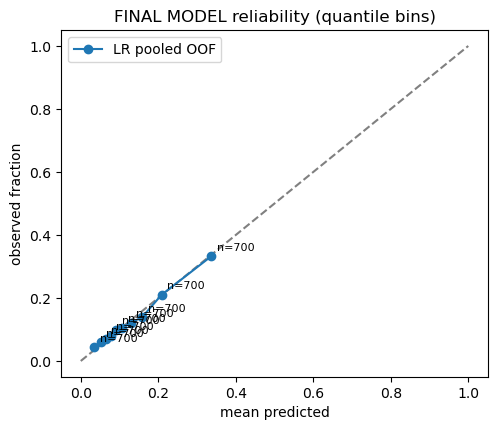

LGBM uncalibrated 0.35348 | platt 0.35342 | isotonic 0.35590
LGBM slope 1.081 | intercept 0.176


In [6]:
sl = LogisticRegression(C=1e6).fit(logit(p_lr).reshape(-1,1), y)
print(f"LR  calibration slope {sl.coef_[0][0]:.3f} | intercept {sl.intercept_[0]:.3f} (ideal 1/0)")
pt, pp = calibration_curve(y, p_lr, n_bins=10, strategy="quantile")
qs = np.quantile(p_lr, np.linspace(0,1,11)); counts = np.histogram(p_lr, bins=qs)[0]
fig, ax = plt.subplots(figsize=(5.5,4.5))
ax.plot([0,1],[0,1],"--",c="gray"); ax.plot(pp, pt, "o-", label="LR pooled OOF")
for x_,t_,n_ in zip(pp,pt,counts): ax.annotate(f"n={n_}",(x_,t_),xytext=(4,4),textcoords="offset points",fontsize=8)
ax.set_xlabel("mean predicted"); ax.set_ylabel("observed fraction")
ax.set_title("FINAL MODEL reliability (quantile bins)"); ax.legend(); plt.show()

def nested_calibrate(p, method, K=5):
    out = np.zeros(len(y))
    for tr_i, te_i in StratifiedKFold(K, shuffle=True, random_state=SEED).split(p, y):
        if method == "isotonic":
            c = IsotonicRegression(out_of_bounds="clip", y_min=1e-4, y_max=1-1e-4)
            c.fit(p[tr_i], y[tr_i]); out[te_i] = c.predict(p[te_i])
        else:
            c = LogisticRegression(C=1e6, max_iter=1000)
            c.fit(logit(p[tr_i]).reshape(-1,1), y[tr_i])
            out[te_i] = c.predict_proba(logit(p[te_i]).reshape(-1,1))[:,1]
    return out
print(f"LGBM uncalibrated {log_loss(y,p_lgbm):.5f} | platt {log_loss(y,nested_calibrate(p_lgbm,'platt')):.5f} "
      f"| isotonic {log_loss(y,nested_calibrate(p_lgbm,'isotonic')):.5f}")
slg = LogisticRegression(C=1e6).fit(logit(p_lgbm).reshape(-1,1), y)
print(f"LGBM slope {slg.coef_[0][0]:.3f} | intercept {slg.intercept_[0]:.3f}")

In [7]:
def skill_ci(p, yy, B=1000):
    r = np.random.default_rng(SEED); s = []
    for _ in range(B):
        i = r.integers(0, len(yy), len(yy))
        s.append(log_loss(yy[i], np.full(len(i), yy[i].mean())) - log_loss(yy[i], p[i]))
    return np.percentile(s, [2.5, 97.5])

age_g = pd.cut(tr_e.age, [0,30,50,70,200], labels=["<30","30-50","50-70","70+"])
for col, series in [("rurality",tr_e.rurality),("region",tr_e.region),("sex",tr_e.sex),
                    ("hospital_type",tr_e.hospital_type),("age_group",age_g),
                    ("ses_q", pd.qcut(tr_e.socioeconomic_index, 5, labels=["Q1","Q2","Q3","Q4","Q5"], duplicates="drop"))]:
    print(f"\n[{col}]")
    for g in series.unique():
        idx = np.where((series == g).values)[0]
        sk = log_loss(y[idx], np.full(len(idx), y[idx].mean())) - log_loss(y[idx], p_lr[idx])
        lo, hi = skill_ci(p_lr[idx], y[idx]) if len(idx) >= 50 else (np.nan, np.nan)
        flag = "  <-- NO BENEFIT/HARM: refer to clinician" if hi < 0 else ""
        print(f"  {str(g):12s} n={len(idx):4d} base={y[idx].mean():.3f} skill={sk:+.4f} CI[{lo:+.4f},{hi:+.4f}]{flag}")
print("\nDEPLOYMENT RULE: any subgroup whose CI excludes 0 on the negative side is"
      "\nflagged for mandatory human review; its predictions are NOT auto-acted on.")


[rurality]
  Rural        n=1243 base=0.156 skill=+0.0345 CI[+0.0183,+0.0508]
  Urban        n=3887 base=0.124 skill=+0.0228 CI[+0.0137,+0.0305]
  Semi-urban   n=1870 base=0.109 skill=+0.0302 CI[+0.0183,+0.0402]

[region]
  Central      n=1529 base=0.129 skill=+0.0374 CI[+0.0220,+0.0512]
  North-East   n=1326 base=0.115 skill=+0.0294 CI[+0.0147,+0.0430]
  West         n=2591 base=0.125 skill=+0.0214 CI[+0.0122,+0.0306]
  South        n=1554 base=0.134 skill=+0.0272 CI[+0.0132,+0.0416]

[sex]
  Female       n=3543 base=0.124 skill=+0.0285 CI[+0.0188,+0.0373]
  Male         n=3457 base=0.128 skill=+0.0273 CI[+0.0184,+0.0354]

[hospital_type]
  General      n=2623 base=0.122 skill=+0.0288 CI[+0.0190,+0.0388]
  Teaching     n=3092 base=0.130 skill=+0.0241 CI[+0.0144,+0.0338]
  District     n=1285 base=0.124 skill=+0.0349 CI[+0.0198,+0.0492]

[age_group]
  30-50        n=2030 base=0.078 skill=+0.0067 CI[+0.0000,+0.0130]
  <30          n= 343 base=0.038 skill=-0.0023 CI[-0.0158,+0.0067]
  5

In [8]:
ent = -(p_lr*np.log(p_lr) + (1-p_lr)*np.log(1-p_lr))
ref = np.argsort(ent)[-len(y)//10:]
keep = np.ones(len(y), bool); keep[ref] = False
r_ll, r2 = [], np.random.default_rng(SEED)
for s in range(200):
    kp = np.ones(len(y), bool)
    kp[r2.choice(len(y), len(y)//10, replace=False)] = False
    r_ll.append(log_loss(y[kp], p_lr[kp]))
print(f"ALL            : {log_loss(y, p_lr):.5f}")
print(f"entropy kept-90: {log_loss(y[keep], p_lr[keep]):.5f}")
print(f"random  kept-90: {np.mean(r_ll):.5f} ± {np.std(r_ll):.5f}  <- control")
print(f"referred set: {y[ref].mean():.1%} event rate | {y[ref].sum()}/{y.sum()} = {y[ref].sum()/y.sum():.1%} of events")

ALL            : 0.35055
entropy kept-90: 0.32061
random  kept-90: 0.35056 ± 0.00267  <- control
referred set: 33.1% event rate | 232/881 = 26.3% of events


In [9]:
TEST_NA = {"creatinine_mg_dl":.0707,"heart_rate_bpm":.0687,"hemoglobin_g_dl":.0657,
           "sodium_mmol_l":.0640,"systolic_bp_mmhg":.0590,"followup_days":.0333}

def stress(model_kind):
    ll_c, ll_s = [], []
    r3 = np.random.default_rng(SEED)
    for tr_i, va_i in StratifiedKFold(5, shuffle=True, random_state=SEED).split(X_raw, y):
        if model_kind == "LR":
            m = Pipeline([("pre", make_pre_lr(NUMS, CATS)), ("clf", LogisticRegression(max_iter=3000, C=BEST_C))])
            m.fit(X_raw.iloc[tr_i], y[tr_i]); pred = lambda X: m.predict_proba(X)[:,1]
        else:
            Xtr = make_pre(NUMS, CATS).fit_transform(X_raw.iloc[tr_i]).astype(np.float32)
            gb = lgb.train(LGBM_PARAMS, lgb.Dataset(Xtr, y[tr_i]), num_boost_round=int(np.median(best_iters)))
            pre_s = make_pre(NUMS, CATS).fit(X_raw.iloc[tr_i])
            pred = lambda X: gb.predict(pre_s.transform(X).astype(np.float32))
        Xv = X_raw.iloc[va_i].reset_index(drop=True).copy()
        ll_c.append(log_loss(y[va_i], pred(Xv)))
        for c_, rate_ in TEST_NA.items():
            rows = r3.choice(len(Xv), int(rate_*len(Xv)), replace=False)
            Xv.loc[rows, c_] = np.nan
            Xv.loc[rows, c_ + "_wasna"] = 1      # <-- F1: deployment-faithful
        ll_s.append(log_loss(y[va_i], pred(Xv)))
    print(f"{model_kind:4s} stress: clean {np.mean(ll_c):.5f} vs test-like {np.mean(ll_s):.5f} "
          f"(degradation {np.mean(ll_s)-np.mean(ll_c):+.5f})")

stress("LR"); stress("LGBM")

LR   stress: clean 0.35203 vs test-like 0.35292 (degradation +0.00089)
LGBM stress: clean 0.35366 vs test-like 0.35376 (degradation +0.00010)


In [10]:
final_lr = Pipeline([("pre", make_pre_lr(NUMS, CATS)),
                     ("clf", LogisticRegression(max_iter=3000, C=BEST_C))]).fit(X_raw, y)
p_test_lr = final_lr.predict_proba(Xte_raw)[:, 1]
print("mean pred LR : OOF", round(p_lr.mean(),5), "-> test", round(p_test_lr.mean(),5))
print("mean pred LGBM: OOF", round(p_lgbm.mean(),5), "| train prevalence", round(y.mean(),5))

top = ["age","prior_admissions_12m","comorbidity_count","n_chronic","prior_x_comorb",
       "length_of_stay_days","missed_appointments_12m"] + [c+"_wasna" for c in NA_COLS]
d = pd.DataFrame({"train": tr_e[top].mean(), "test": te_e[top].mean()})
d["delta"] = d["test"] - d["train"]
print("\nmarginal drift (top predictors):\n", d.round(4).sort_values("delta", key=abs, ascending=False))

Xcf = Xte_raw.copy()
for c in NA_COLS: Xcf[c+"_wasna"] = tr_e[c].isna().mean()   # flags at TRAIN rates
print("\nLR test mean pred with flags neutralized:", round(final_lr.predict_proba(Xcf)[:,1].mean(), 5))
print("-> if this drops to ~0.128: upshift is a missingness artifact (add no-flag variant as sensitivity).")
print("-> if it stays ~0.138: upshift is legitimate covariate shift (age/prior-admissions).")

mean pred LR : OOF 0.12578 -> test 0.1377
mean pred LGBM: OOF 0.12296 | train prevalence 0.12586

marginal drift (top predictors):
                            train     test   delta
age                      56.8221  58.4475  1.6254
prior_x_comorb            1.2764   1.4107  0.1342
length_of_stay_days       4.5399   4.6367  0.0968
prior_admissions_12m      0.7963   0.8457  0.0494
n_chronic                 0.5239   0.5697  0.0458
comorbidity_count         1.5503   1.5907  0.0404
creatinine_mg_dl_wasna    0.0483   0.0707  0.0224
heart_rate_bpm_wasna      0.0481   0.0687  0.0205
sodium_mmol_l_wasna       0.0444   0.0640  0.0196
hemoglobin_g_dl_wasna     0.0463   0.0657  0.0194
systolic_bp_mmhg_wasna    0.0441   0.0590  0.0149
followup_days_wasna       0.0233   0.0333  0.0100
missed_appointments_12m   0.8234   0.8297  0.0062

LR test mean pred with flags neutralized: 0.13754
-> if this drops to ~0.128: upshift is a missingness artifact (add no-flag variant as sensitivity).
-> if it stays ~0

In [11]:
CATS_nc = [c for c in CATS if c != "care_pathway"]
oof_nc = run_repeated_cv_lr(BEST_C, CATS_nc, tag="LR-noCP")
p_nc = oof_nc.mean(0)
ci_cp = paired_bootstrap(p_nc, p_lr)
print(f"WITH {np.mean(lls_lr):.5f} | WITHOUT {np.mean([log_loss(y,oof_nc[r]) for r in range(3)]):.5f} "
      f"| drop cost CI [{ci_cp[0]:+.5f}, {ci_cp[1]:+.5f}] -> keep WITH; ablation = §5 sensitivity")

  LR-noCP repeat 1: logloss 0.35150
  LR-noCP repeat 2: logloss 0.35211
  LR-noCP repeat 3: logloss 0.35053
WITH 0.35102 | WITHOUT 0.35138 | drop cost CI [-0.00054, +0.00135] -> keep WITH; ablation = §5 sensitivity


In [12]:
enc = final_lr.named_steps["pre"].named_transformers_["cat"]
names = list(NUMS) + list(enc.get_feature_names_out(CATS))
or_tab = pd.Series(np.exp(final_lr.named_steps["clf"].coef_[0]), index=names)
or_tab = or_tab.sort_values(key=lambda s: abs(np.log(s)), ascending=False)
print("TOP 10 ORs (numerics per 1 SD; categoricals vs first level):")
print(or_tab.head(10).round(3).to_string())

TOP 10 ORs (numerics per 1 SD; categoricals vs first level):
age                                        1.549
discharge_disposition_Rehab                1.429
care_pathway_P4                            1.413
prior_admissions_12m                       1.351
comorbidity_count                          1.242
rurality_Semi-urban                        0.808
discharge_disposition_Home_with_support    1.223
followup_days                              1.197
heart_failure                              1.136
hospital_type_Teaching                     1.119


In [13]:
print(f"""
================ PRE-REGISTRATION ================
#  model            CV LL (pooled)      pre-registered LB
1  constant         0.37844            0.3817-0.3820 (shift) / 0.3784 (no shift)
2  LR C={BEST_C} (FINAL) {np.mean(lls_lr):.5f}          {np.mean(lls_lr):.5f} + delta + ~0.001
-  LGBM+platt       {np.mean(lls_lg):.5f}          NOT submitted (rejected by pre-registered rule)
TEST: LB2 - LB1 ~= {np.mean(lls_lr):.5f} - 0.37844 = {np.mean(lls_lr)-0.37844:.5f}  -> skill transferred
===================================================""")


================ PRE-REGISTRATION ================
#  model            CV LL (pooled)      pre-registered LB
1  constant         0.37844            0.3817-0.3820 (shift) / 0.3784 (no shift)
2  LR C=0.1 (FINAL) 0.35102          0.35102 + delta + ~0.001
-  LGBM+platt       0.35559          NOT submitted (rejected by pre-registered rule)
TEST: LB2 - LB1 ~= 0.35102 - 0.37844 = -0.02742  -> skill transferred


In [14]:
p_final = np.clip(p_test_lr, 1e-4, 1 - 1e-4)          # p_test_lr from Cell 10 (frozen spec, 100% train fit)
sub = test[[ID]].copy(); sub[TARGET] = p_final
assert (sub[ID].values == test[ID].values).all()
assert sub[TARGET].notna().all() and ((sub[TARGET] > 0) & (sub[TARGET] < 1)).all()
sub.to_csv("../submissions/submission_03_slgbm.csv", index=False)
np.save("p_test_lr.npy", p_final)
print("saved submission_03_slgbm.csv | mean test pred:", round(p_final.mean(), 5),
      "| train prevalence:", round(y.mean(), 5))

saved submission_03_slgbm.csv | mean test pred: 0.1377 | train prevalence: 0.12586
